# Expirements for the Image Sticthing App

In [1]:
import os
import cv2 
import numpy as np
import pandas as pd
import networkx as nx
from itertools import compress
import matplotlib.pyplot as plt
import main
import utils.file_utils as file_utils
from image_stitching import models
%load_ext autoreload
%autoreload 2

## Using OpenCV Sticther

In [12]:
img_paths = file_utils.get_image_files("/home/schmidtg/coding_projetcs/local-image-features-apps/src/image_stitching/datasets/example-data/flower")
images = [cv2.imread(p) for p in img_paths]

stitcher = cv2.Stitcher_create()
status, panorama = stitcher.stitch(images)

if status == cv2.Stitcher_OK:
    cv2.imwrite("../../output/cv_panorama.jpg", panorama)
    print("Panorama saved!")
else:
    print("Error during stitching:", status)

Panorama saved!


## Critical Steps
All the features accross all the images need to be detetected, described and matched with each other. 

Important aspects:
1. Detect all features
2. Compute all descriptors
2. Save ids of features
3. Know which features belong to which image
5. Match all features with closest K neighbours
6. Remove invalid matches (features from the same image)

### Detect All Features and Compute Descriptors

In [2]:
img_paths = file_utils.get_image_files("/home/schmidtg/coding_projetcs/local-image-features-apps/src/image_stitching/datasets/example-data/flower")
orb = cv2.ORB_create()

img_id_bounds = np.array([0], dtype=np.uint32)  # indicated at which ID an image starts/end
N = 0
des = np.empty((0,32), dtype=np.uint8) # data type is crucial!
img_ids = np.empty((0))
kps = ()

for img_id, img_path in enumerate(img_paths): 
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    kp_new, des_new = orb.detectAndCompute(img, None)  # type: ignore
    des = np.vstack((des, des_new))
    kps +=  kp_new
    N_new = len(des_new)
    N += N_new
    img_id_bounds = np.append(img_id_bounds, N)
    img_ids_new = np.full((N_new), img_id)
    img_ids = np.concatenate((img_ids, img_ids_new), axis=0)

In [4]:
print("Total features detected accross images:\n\t", len(kps))
print("dType of kps:\n\t", type(kps))
print("dType of elements in kps:\n\t", type(kps[0]))
print("Id of the first feature belonging to each image\n\t", img_id_bounds)
print("img ids of each feature:\n\t", img_ids)
print("dType of des:\n\t", type(des))
print("Descriptors of features:\n", des)
print("Length of a descriptors in bytes:\n", len(des[0]) )

Total features detected accross images:
	 2000
dType of kps:
	 <class 'tuple'>
dType of elements in kps:
	 <class 'cv2.KeyPoint'>
Id of the first feature belonging to each image
	 [   0  500 1000 1500 2000]
img ids of each feature:
	 [0. 0. 0. ... 3. 3. 3.]
dType of des:
	 <class 'numpy.ndarray'>
Descriptors of features:
 [[129  76  31 ... 248 161 168]
 [ 10  19 254 ... 174  37 213]
 [173 213 125 ... 187  68  97]
 ...
 [ 90   2 230 ... 164  60  84]
 [ 59 183 112 ... 222 219 157]
 [ 61  95  98 ... 191 120 185]]
Length of a descriptors in bytes:
 32


### Save Features with Descriptors and ImageID by Feature ID into Pandas Dataframe

In [32]:
matching_df = pd.DataFrame(
    {"Descriptor" : list(des),
     "ImgId" : img_ids})
convert_dict ={"ImgId": np.uint8}  # dont expect more than 2^8 / 255 images
matching_df = matching_df.astype(convert_dict)
print(matching_df.dtypes)
print("Descriptor dtype:", type(matching_df["Descriptor"].iloc[0]), matching_df["Descriptor"].iloc[0].dtype)
matching_df.head()

Descriptor    object
ImgId          uint8
dtype: object
Descriptor dtype: <class 'numpy.ndarray'> uint8


,Descriptor,ImgId
0,"[55, 98, 68, 133, 46, 2, 206, 120, 0, 226, 213...",0
1,"[115, 110, 107, 37, 32, 201, 79, 226, 169, 228...",0
2,"[120, 205, 142, 251, 157, 242, 230, 231, 85, 1...",0
3,"[7, 180, 157, 83, 24, 175, 169, 156, 174, 113,...",0
4,"[23, 125, 73, 164, 10, 195, 79, 226, 39, 224, ...",0


### Macth All Features

In [33]:
# get descriptors from table into correct format
x = np.stack(list(matching_df["Descriptor"])) # x = des


# Define FLANN parameters and match descriptors
# from https://docs.opencv.org/4.x/dc/dc3/tutorial_py_matcher.html
FLANN_INDEX_LSH = 6
index_params= dict(algorithm = FLANN_INDEX_LSH,
                   table_number = 6, # 12
                   key_size = 12,     # 20
                   multi_probe_level = 1) #2
search_params = dict(checks=50)   # or pass empty dictionary
flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(x,x, k=10)

# 2nd Method, Not Working
# FLANN_INDEX_KDTREE = 0
# index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
# search_params = dict(checks=50)
# flann = cv2.FlannBasedMatcher(index_params, search_params)
# matches = flann.knnMatch(des, des, k=2)

In [ ]:
# we see that the 1st match, is always matched the result of the keypoint being matched with itself
for M in matches[0:10]:
    m = M[0]
    print(m.queryIdx, m.trainIdx)

0 0
1 1
2 2
3 3
4 4
5 5
6 6
7 7
8 8
9 9


In [35]:
type(matches), type(matches[0]), type(matches[0][0])

(tuple, tuple, cv2.DMatch)

In [36]:
# so remove the 1st match for all of them - redundant because of remove_invalid_matches
matches1 = tuple((m[1:]) for m in matches)

In [37]:
matches_list, matched_col = list(), list()

for i, m_tuple in enumerate(matches):
    m_list = list(m_tuple[1:])
    matches_list.append(m_list)
    matched_col.append(np.array([m.trainIdx for m in m_list]))

In [38]:
type(matches_list), type(matches_list[0]), type(matches)

(list, list, tuple)

In [39]:
matched_col[0:5]

[array([ 126, 2004,  939, 1734, 2125, 3827, 4311,   61, 3902]),
 array([   4,  121, 2531, 2949, 5434, 4234, 4280, 4542,  411]),
 array([ 114, 2706, 4295, 4370, 1077, 1034, 3193, 4377, 2008]),
 array([5088, 5430, 4466,  528,  653, 1614, 2443, 2776, 3695]),
 array([   1, 2645, 2533, 3828,  989, 1465, 3626, 3564, 1443])]

In [40]:
matching_df['Matched_Ids'] = matched_col

In [41]:
matching_df.head()

,Descriptor,ImgId,Matched_Ids
0,"[55, 98, 68, 133, 46, 2, 206, 120, 0, 226, 213...",0,"[126, 2004, 939, 1734, 2125, 3827, 4311, 61, 3..."
1,"[115, 110, 107, 37, 32, 201, 79, 226, 169, 228...",0,"[4, 121, 2531, 2949, 5434, 4234, 4280, 4542, 411]"
2,"[120, 205, 142, 251, 157, 242, 230, 231, 85, 1...",0,"[114, 2706, 4295, 4370, 1077, 1034, 3193, 4377..."
3,"[7, 180, 157, 83, 24, 175, 169, 156, 174, 113,...",0,"[5088, 5430, 4466, 528, 653, 1614, 2443, 2776,..."
4,"[23, 125, 73, 164, 10, 195, 79, 226, 39, 224, ...",0,"[1, 2645, 2533, 3828, 989, 1465, 3626, 3564, 1..."


In [42]:
# convert matched descriptor ids to img ids 
def descriptor_id_to_img_id(id,bounds) -> int:
    """
    Get the associated Image ID for the given Descriptor ID, using the given bounds. 
    Returns:
        int: in range from 0 to length of bounds-1
    """
    return np.searchsorted(bounds, id, side='right') - 1

def matched_ids_to_img_ids(row, bounds):
    matched_ids = row['Matched_Ids']
    img_ids = [descriptor_id_to_img_id(id, bounds) for id in matched_ids]
    return np.array(img_ids)

matching_df['Matched_ImgIds'] = matching_df.apply(matched_ids_to_img_ids, 
                                                  axis=1, 
                                                  args=(img_id_bounds,))

In [43]:
for m in matches_list[0:5]:
    print(len(m))

9
9
9
9
9


In [44]:
matching_df.head()

,Descriptor,ImgId,Matched_Ids,Matched_ImgIds
0,"[55, 98, 68, 133, 46, 2, 206, 120, 0, 226, 213...",0,"[126, 2004, 939, 1734, 2125, 3827, 4311, 61, 3...","[0, 4, 1, 3, 4, 7, 8, 0, 7]"
1,"[115, 110, 107, 37, 32, 201, 79, 226, 169, 228...",0,"[4, 121, 2531, 2949, 5434, 4234, 4280, 4542, 411]","[0, 0, 5, 5, 10, 8, 8, 9, 0]"
2,"[120, 205, 142, 251, 157, 242, 230, 231, 85, 1...",0,"[114, 2706, 4295, 4370, 1077, 1034, 3193, 4377...","[0, 5, 8, 8, 2, 2, 6, 8, 4]"
3,"[7, 180, 157, 83, 24, 175, 169, 156, 174, 113,...",0,"[5088, 5430, 4466, 528, 653, 1614, 2443, 2776,...","[10, 10, 8, 1, 1, 3, 4, 5, 7]"
4,"[23, 125, 73, 164, 10, 195, 79, 226, 39, 224, ...",0,"[1, 2645, 2533, 3828, 989, 1465, 3626, 3564, 1...","[0, 5, 5, 7, 1, 2, 7, 7, 2]"


In [45]:
# remove Matched Ids of descriptors that belong to the same image
def remove_invalid_matches(row, matches_list: list) -> pd.Series:
    """
    Removes Ids from Matched_Ids that are the are from the same Image (ImgId).
    Also modifies the list matches_list passed as an argument.
    Args:
        row: a row from a pandas dataframe

    Returns:
        series: a series for containing the updated Matched_Ids and Matched_ImgIds, with invalid values removed.
    """
    index, matched_ids, img_ids, imgId = int(row.name), row['Matched_Ids'], row['Matched_ImgIds'], row['ImgId'] 
    indeces_to_remove = np.where(img_ids == imgId)
    # create mask to remove values
    mask = np.ones(len(matched_ids), dtype=bool)
    mask[indeces_to_remove] = False
    matched_ids = matched_ids[mask,...]
    img_ids = img_ids[mask,...]
    matches_list[index] = list(compress(matches_list[index], mask))
    return pd.Series([matched_ids, img_ids])

In [46]:
matching_df[["Matched_Ids", "Matched_ImgIds"]] = matching_df.apply(remove_invalid_matches, axis=1, args=(matches_list,))
matching_df.head()

,Descriptor,ImgId,Matched_Ids,Matched_ImgIds
0,"[55, 98, 68, 133, 46, 2, 206, 120, 0, 226, 213...",0,"[2004, 939, 1734, 2125, 3827, 4311, 3902]","[4, 1, 3, 4, 7, 8, 7]"
1,"[115, 110, 107, 37, 32, 201, 79, 226, 169, 228...",0,"[2531, 2949, 5434, 4234, 4280, 4542]","[5, 5, 10, 8, 8, 9]"
2,"[120, 205, 142, 251, 157, 242, 230, 231, 85, 1...",0,"[2706, 4295, 4370, 1077, 1034, 3193, 4377, 2008]","[5, 8, 8, 2, 2, 6, 8, 4]"
3,"[7, 180, 157, 83, 24, 175, 169, 156, 174, 113,...",0,"[5088, 5430, 4466, 528, 653, 1614, 2443, 2776,...","[10, 10, 8, 1, 1, 3, 4, 5, 7]"
4,"[23, 125, 73, 164, 10, 195, 79, 226, 39, 224, ...",0,"[2645, 2533, 3828, 989, 1465, 3626, 3564, 1443]","[5, 5, 7, 1, 2, 7, 7, 2]"


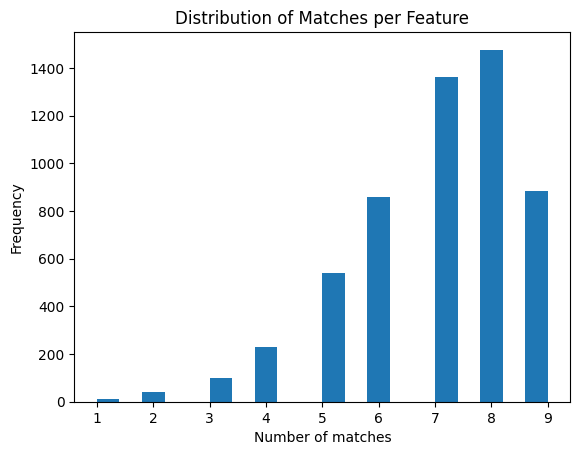

In [47]:
lengths = matching_df["Matched_Ids"].apply(len)
plt.hist(lengths, bins=20)
plt.xlabel("Number of matches")
plt.ylabel("Frequency")
plt.title("Distribution of Matches per Feature")
plt.show()

In [48]:
# reduce mathces
for col in ["Matched_Ids", "Matched_ImgIds"]:
    matching_df[col] = matching_df[col].map(lambda x: x[:5])

In [50]:
matching_df.head()

,Descriptor,ImgId,Matched_Ids,Matched_ImgIds
0,"[55, 98, 68, 133, 46, 2, 206, 120, 0, 226, 213...",0,"[2004, 939, 1734, 2125, 3827]","[4, 1, 3, 4, 7]"
1,"[115, 110, 107, 37, 32, 201, 79, 226, 169, 228...",0,"[2531, 2949, 5434, 4234, 4280]","[5, 5, 10, 8, 8]"
2,"[120, 205, 142, 251, 157, 242, 230, 231, 85, 1...",0,"[2706, 4295, 4370, 1077, 1034]","[5, 8, 8, 2, 2]"
3,"[7, 180, 157, 83, 24, 175, 169, 156, 174, 113,...",0,"[5088, 5430, 4466, 528, 653]","[10, 10, 8, 1, 1]"
4,"[23, 125, 73, 164, 10, 195, 79, 226, 39, 224, ...",0,"[2645, 2533, 3828, 989, 1465]","[5, 5, 7, 1, 2]"


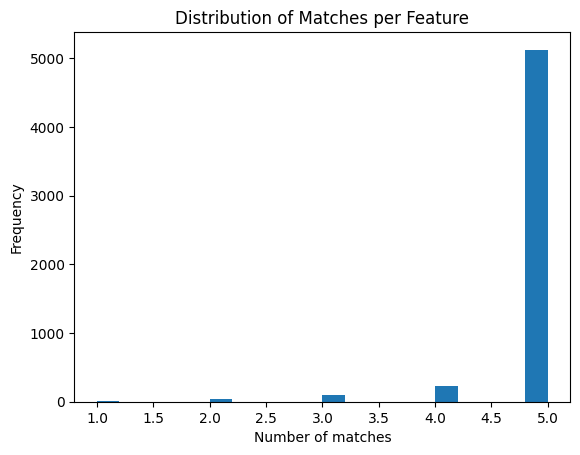

In [51]:
lengths = matching_df["Matched_Ids"].apply(len)
plt.hist(lengths, bins=20)
plt.xlabel("Number of matches")
plt.ylabel("Frequency")
plt.title("Distribution of Matches per Feature")
plt.show()

In [747]:
np.stack(matching_df[(matching_df["ImgId"] == 0)]["Descriptor"])

array([[ 55,  98,  68, ..., 183, 122, 148],
       [115, 110, 107, ..., 246,   3,  92],
       [120, 205, 142, ..., 222, 248,  10],
       ...,
       [ 34,   0, 214, ...,   8,  49, 136],
       [107,  50, 251, ..., 132,   7, 215],
       [163, 126,  98, ..., 196,  98, 221]], shape=(500, 32), dtype=uint8)

## Determine How Many Matches Between Images

In [87]:
# Get the counts of imag matches
img_id_stats_df = matching_df.explode('Matched_ImgIds')
result = (
    img_id_stats_df
    .groupby(['ImgId', 'Matched_ImgIds'])
    .size()
    .reset_index(name='Count')
    .rename(columns={'Matched_ImgIds': 'MatchedWith'})
)

print(result)

     ImgId  MatchedWith  Count
0        0            1    294
1        0            2    195
2        0            3    265
3        0            4    199
4        0            5    146
..     ...          ...    ...
105     10            5    161
106     10            6    174
107     10            7    425
108     10            8    171
109     10            9    186

[110 rows x 3 columns]


## Match Ratio Between Images 

In [88]:
n_images = len(img_paths)
match_ratio = np.zeros((n_images,n_images))
i = 0

for row in range (n_images):
    for col in range (n_images):
        if row == col:
            continue
        first_id = img_id_bounds[row]
        last_id = img_id_bounds[row+1]
        n_features = last_id - first_id
        n_matches = result.iloc[i]['Count']
        match_ratio[row][col] = n_matches / n_features
        i+=1

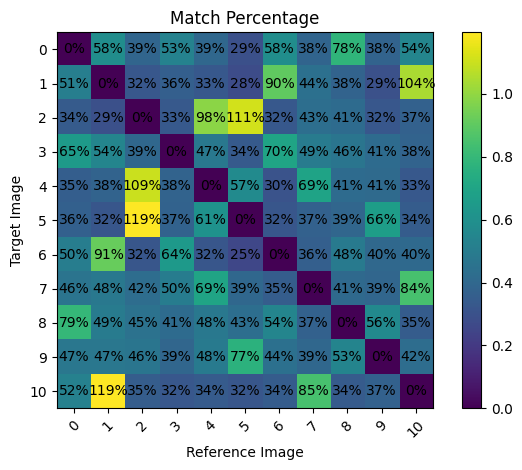

In [89]:
fig, ax = plt.subplots()

cax = ax.imshow(match_ratio)

# Add colorbar
plt.colorbar(cax)

# Axis labels (optional)
 
labels = [f"{i}" for i in range(n_images)]
ax.set_xticks(range(n_images))
ax.set_yticks(range(n_images))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

# Rotate x labels for readability
plt.xticks(rotation=45)

# Annotate each cell with value
for i in range(n_images):
    for j in range(n_images):
        display_value = f"{int(match_ratio[i, j]*100)}%"
        ax.text(j, i, display_value, ha="center", va="center")

plt.xlabel("Reference Image")
plt.ylabel("Target Image")
plt.title("Match Percentage")

plt.tight_layout()
plt.show()

## Connectivity Graph From Match Ratios

In [91]:
def init_graph(n_images, match_ratio):
    graph = nx.Graph()

    for i in range(n_images):
        for j in range(i+1, n_images):
            mutual_ratio = match_ratio[i,j] 
            mutual_ratio += match_ratio[j,i]
            mutual_ratio /= 2
            if mutual_ratio > 0.5:
                inverse_ratio = 1 - mutual_ratio
                ic = models.ImageConnection(
                    weight=inverse_ratio,
                    inliers=0,
                    valid_connection=models.ValidConnection.UNKNOWN,
                    homography=np.identity(3),
                    reference=i,
                    target=j
                    )
                graph.add_edge(i, j, weight=ic.weight, data=ic)  # invert for MST

    return graph

0: medium08.jpg
1: medium11.jpg
2: medium04.jpg
3: medium09.jpg
4: medium03.jpg
5: medium05.jpg
6: medium10.jpg
7: medium02.jpg
8: medium07.jpg
9: medium06.jpg
10: medium01.jpg


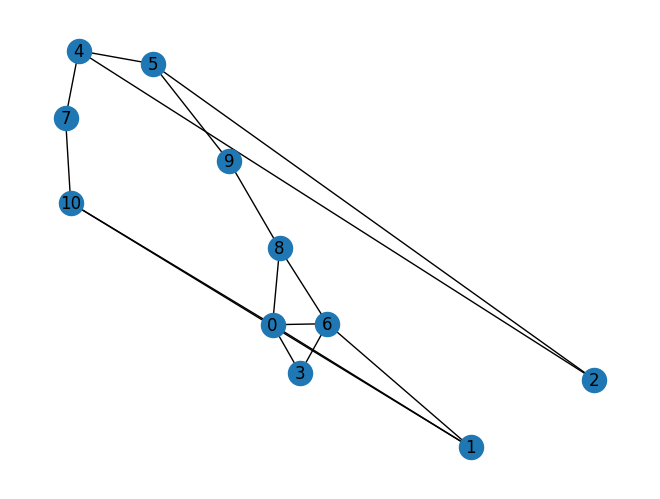

In [92]:
fully_connected_graph = init_graph(n_images, match_ratio)

pos = nx.spring_layout(fully_connected_graph)

for i, path in enumerate(img_paths):
    print(f"{i}: {os.path.basename(path)}")

# Draw graph
nx.draw(fully_connected_graph, pos, with_labels=True)
plt.show()


In [61]:
edge_data = fully_connected_graph[0][1]['data']

print(edge_data)                 
print(edge_data.weight) 
print(edge_data.valid_connection)

ImageConnection(weight=np.float64(0.45100000000000007), inliers=0, valid_connection=<ValidConnection.UNKNOWN: -1>, homography=array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]]), reference=0, target=1)
0.45100000000000007
ValidConnection.UNKNOWN


### Most Well Connected Image

In [62]:
top_matches = (
    result
    .sort_values(['ImgId', 'Count'], ascending=[True, False])
    .groupby('ImgId')['MatchedWith']
    .apply(list)
    .to_dict()
)

top_matches

{0: [8, 1, 6, 10, 3, 4, 2, 7, 9, 5],
 1: [10, 6, 0, 7, 8, 3, 4, 2, 9, 5],
 2: [5, 4, 7, 8, 10, 0, 3, 6, 9, 1],
 3: [6, 0, 1, 7, 4, 8, 9, 2, 10, 5],
 4: [2, 7, 5, 8, 9, 1, 3, 0, 10, 6],
 5: [2, 9, 4, 8, 3, 7, 0, 10, 1, 6],
 6: [1, 3, 0, 8, 10, 9, 7, 2, 4, 5],
 7: [10, 4, 3, 1, 0, 2, 8, 5, 9, 6],
 8: [0, 9, 6, 1, 4, 2, 5, 3, 7, 10],
 9: [5, 8, 4, 0, 1, 2, 6, 10, 7, 3],
 10: [1, 7, 0, 9, 2, 6, 4, 8, 3, 5]}

## Determine Matches Between 2 specific Images From matching_df

1. Reduce matching_df to entries containing reference image (ImageID) and has target Image in "Matched_ImgIds" column.
2. Create macth tuple for each row, saying which keypoint from reference is matched to which keypoint in traget.
3. Combine the match tuples from all the rows in the   

In [63]:
matching_df.head()

,Descriptor,ImgId,Matched_Ids,Matched_ImgIds
0,"[55, 98, 68, 133, 46, 2, 206, 120, 0, 226, 213...",0,"[2004, 939, 1734, 2125, 3827]","[4, 1, 3, 4, 7]"
1,"[115, 110, 107, 37, 32, 201, 79, 226, 169, 228...",0,"[2531, 2949, 5434, 4234, 4280]","[5, 5, 10, 8, 8]"
2,"[120, 205, 142, 251, 157, 242, 230, 231, 85, 1...",0,"[2706, 4295, 4370, 1077, 1034]","[5, 8, 8, 2, 2]"
3,"[7, 180, 157, 83, 24, 175, 169, 156, 174, 113,...",0,"[5088, 5430, 4466, 528, 653]","[10, 10, 8, 1, 1]"
4,"[23, 125, 73, 164, 10, 195, 79, 226, 39, 224, ...",0,"[2645, 2533, 3828, 989, 1465]","[5, 5, 7, 1, 2]"


In [64]:
def get_sub_matching_dataframe(id1, id2, matching_df):
    """
    Reduces matching_df to a subset containing features that are matched between 2 specific images. 

    Args:
        id1 (int): what 'ImgId' column should be equal to
        id2 (int): what should be in 'Matched_ImgIds' column
        matching_df (pandas dataframe): 

    Returns:
        pandas dataframe: subset of matching_df
    """
    sub_matching_df = matching_df[
        (matching_df["ImgId"] == id1) &
        (matching_df['Matched_ImgIds'].apply(lambda x: id2 in x))
        ]
    return sub_matching_df

def generate_id_pair(row, id2: int):
    feature_id_img1 = int(row.Index)  # id of feature in reference image 
    matched_ids = np.array(row.Matched_Ids)  # ids of matched feature
    img_ids = np.array(row.Matched_ImgIds)  # ids of images of matched features
    mask = img_ids == id2
    valid_id = matched_ids[mask]
    new_entries = [(feature_id_img1, int(feature_id_img2)) for feature_id_img2 in valid_id]
    return new_entries


def determine_matches_between_image_pair(id1, id2, matching_df):
    sub_matching_df = get_sub_matching_dataframe(id1, id2, matching_df)
    id_matches = [] 
    for row in sub_matching_df.itertuples(index=True):
        id_matches.extend(generate_id_pair(row, id2))
    return id_matches


In [65]:
id1 = 0
id2 = 2
matched_ids = determine_matches_between_image_pair(id1, id2, matching_df)
len(matched_ids), matched_ids

(195,
 [(2, 1077),
  (2, 1034),
  (4, 1465),
  (5, 1084),
  (9, 1318),
  (18, 1167),
  (19, 1259),
  (20, 1069),
  (20, 1078),
  (21, 1231),
  (23, 1222),
  (23, 1256),
  (27, 1352),
  (30, 1313),
  (35, 1135),
  (36, 1461),
  (38, 1052),
  (39, 1085),
  (40, 1409),
  (41, 1357),
  (42, 1369),
  (46, 1248),
  (47, 1061),
  (56, 1113),
  (56, 1079),
  (58, 1085),
  (59, 1485),
  (59, 1304),
  (65, 1063),
  (67, 1131),
  (71, 1263),
  (73, 1382),
  (76, 1029),
  (77, 1493),
  (79, 1137),
  (80, 1111),
  (81, 1210),
  (88, 1191),
  (89, 1493),
  (89, 1129),
  (96, 1121),
  (96, 1207),
  (105, 1047),
  (106, 1298),
  (107, 1231),
  (112, 1266),
  (114, 1026),
  (114, 1221),
  (119, 1266),
  (120, 1330),
  (121, 1120),
  (121, 1465),
  (124, 1169),
  (127, 1231),
  (128, 1278),
  (129, 1084),
  (131, 1085),
  (137, 1291),
  (138, 1069),
  (144, 1292),
  (146, 1168),
  (154, 1121),
  (157, 1085),
  (157, 1084),
  (161, 1210),
  (169, 1120),
  (170, 1151),
  (172, 1274),
  (175, 1153),
  (181

In [66]:
# image to match / stitch
get_sub_matching_dataframe(id1, id2, matching_df)

,Descriptor,ImgId,Matched_Ids,Matched_ImgIds
2,"[120, 205, 142, 251, 157, 242, 230, 231, 85, 1...",0,"[2706, 4295, 4370, 1077, 1034]","[5, 8, 8, 2, 2]"
4,"[23, 125, 73, 164, 10, 195, 79, 226, 39, 224, ...",0,"[2645, 2533, 3828, 989, 1465]","[5, 5, 7, 1, 2]"
5,"[220, 163, 157, 178, 168, 15, 76, 189, 174, 18...",0,"[5055, 5244, 3404, 1084, 3062]","[10, 10, 6, 2, 6]"
9,"[101, 229, 233, 65, 156, 79, 199, 141, 66, 181...",0,"[1318, 853, 4273, 4296, 2776]","[2, 1, 8, 8, 5]"
18,"[12, 74, 39, 177, 100, 226, 232, 146, 92, 67, ...",0,"[1996, 967, 1957, 2839, 1167]","[3, 1, 3, 5, 2]"
...,...,...,...,...
468,"[33, 83, 99, 76, 116, 19, 226, 120, 69, 192, 1...",0,"[571, 587, 1218, 2004, 3109]","[1, 1, 2, 4, 6]"
473,"[26, 155, 98, 191, 3, 208, 156, 103, 168, 68, ...",0,"[678, 708, 3310, 540, 1197]","[1, 1, 6, 1, 2]"
480,"[91, 137, 151, 254, 179, 196, 61, 231, 173, 19...",0,"[1588, 1105, 2063, 567, 3009]","[3, 2, 4, 1, 6]"
488,"[57, 107, 91, 233, 112, 143, 107, 55, 33, 64, ...",0,"[3328, 4512, 3231, 3940, 1050]","[6, 9, 6, 7, 2]"


In [67]:
def get_homogrphy(kps, matched_ids):
    src = np.empty((len(matched_ids),2), dtype=np.float32)  # coords of features from reference image 
    dst = np.empty((len(matched_ids),2), dtype=np.float32)  # coords of features from target image 

    for i, id_pair in enumerate(matched_ids):
        kp_id1, kp_id2 = id_pair  # get ids of features 
        kp1, kp2 = kps[kp_id1], kps[kp_id2]  # use ids of features to get their objs
        src[i,0] = kp1.pt[0]  # x coord
        src[i,1] = kp1.pt[1]  # y coord
        dst[i,0] = kp2.pt[0]  # x coord
        dst[i,1] = kp2.pt[1]  # y coord

    H, mask =  cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
    return H, mask  

H, mask = get_homogrphy(kps, matched_ids)

In [68]:
# number of inliers
np.count_nonzero(mask)

24

In [69]:
H

array([[-7.08005209e-01,  4.41152223e-01,  5.45322657e+02],
       [-7.17406328e-01,  4.44778188e-01,  5.53399956e+02],
       [-1.29776200e-03,  8.07488330e-04,  1.00000000e+00]])

In [70]:
def verify_connection(n_inliers, max_features, threshold) -> bool:
    inlier_percentage = n_inliers / max_features
    is_connected = inlier_percentage > threshold
    return is_connected

def get_connection_between(img_id1, img_id2, img_id_bounds, kps, matching_df, threshold) -> models.ImageConnection:
    # case 1 img_id1 is reference
    IC = get_connection_from_and_to(img_id1, img_id2, img_id_bounds, kps, matching_df, threshold)
    if IC.valid_connection == models.ValidConnection.CONNECTED:
        return IC
    
    # case 2 img_id2 is reference
    IC = get_connection_from_and_to(img_id2, img_id1, img_id_bounds, kps, matching_df, threshold)
    if IC.valid_connection == models.ValidConnection.CONNECTED:
        return IC
    
    IC = models.ImageConnection(
        weight=1.0,
        inliers=0,
        valid_connection=models.ValidConnection.NOTCONNECTED,
        homography=np.identity(3),
        reference=img_id1,
        target=img_id2
    )
    return IC

    
def get_connection_from_and_to(img_id1, img_id2, img_id_bounds, kps, matching_df, threshold) -> models.ImageConnection:
    matched_ids = determine_matches_between_image_pair(img_id1, img_id2, matching_df)
    H, mask = get_homogrphy(kps, matched_ids)
    n_inliers = np.count_nonzero(mask)
    max_features = img_id_bounds[img_id1+1] - img_id_bounds[img_id1]
    is_connected = verify_connection(n_inliers, max_features, threshold) 
    if is_connected:
        valid_connection = models.ValidConnection.CONNECTED
    else:
        valid_connection = models.ValidConnection.NOTCONNECTED
    IC = models.ImageConnection(
        weight=1 - (n_inliers/max_features),
        inliers=n_inliers,
        valid_connection=valid_connection,
        homography=H,
        reference=img_id1,
        target=img_id2
    )
    return IC

In [71]:
ic = get_connection_from_and_to(id1, id2, img_id_bounds, kps, matching_df, threshold=0.25)
ic

ImageConnection(weight=np.float64(0.952), inliers=24, valid_connection=<ValidConnection.NOTCONNECTED: 0>, homography=array([[-7.08005209e-01,  4.41152223e-01,  5.45322657e+02],
       [-7.17406328e-01,  4.44778188e-01,  5.53399956e+02],
       [-1.29776200e-03,  8.07488330e-04,  1.00000000e+00]]), reference=0, target=2)

In [72]:
ic = get_connection_between(id1, id2, img_id_bounds, kps, matching_df, threshold=0.25)
ic

ImageConnection(weight=1.0, inliers=0, valid_connection=<ValidConnection.NOTCONNECTED: 0>, homography=array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]]), reference=0, target=2)

In [73]:
img1 = cv2.imread(img_paths[id1], cv2.IMREAD_COLOR_RGB)
img2 = cv2.imread(img_paths[id2], cv2.IMREAD_COLOR_RGB)

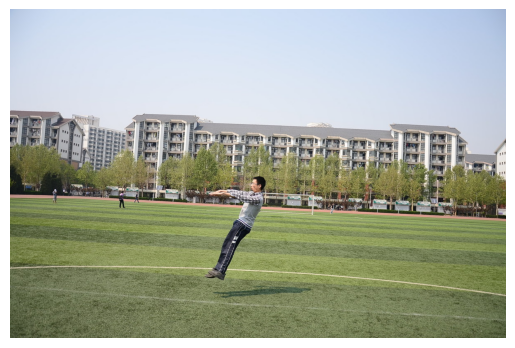

In [74]:
def stitch_images2(img1, img2, H):
    """
    Stitch img2 onto img1 using homography H (img2 -> img1)
    img1 is the base canvas
    """
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    # Corners of img2
    corners_img2 = np.array([[0,0],[0,h2],[w2,h2],[w2,0]], dtype=np.float32).reshape(-1,1,2)
    # Warp corners into img1's frame using H
    warped_corners = cv2.perspectiveTransform(corners_img2, H)

    # Corners of img1
    corners_img1 = np.array([[0,0],[0,h1],[w1,h1],[w1,0]], dtype=np.float32).reshape(-1,1,2)

    # All corners together to find canvas size
    all_corners = np.concatenate((warped_corners, corners_img1), axis=0)
    [xmin, ymin] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
    [xmax, ymax] = np.int32(all_corners.max(axis=0).ravel() + 0.5)

    # Translation matrix to shift everything into positive coordinates
    translation = np.array([[1,0,-xmin],[0,1,-ymin],[0,0,1]])

    # Warp img2 into canvas
    result = cv2.warpPerspective(img2, translation @ H, (xmax - xmin, ymax - ymin))
    # Place img1 into canvas
    result[-ymin:h1 - ymin, -xmin:w1 - xmin] = img1

    return result

stitched = stitch_images2(img2, img1, H) # image 2 is the base actually, 

# Display inline
plt.imshow(stitched, cmap="gray")
plt.axis('off')  # hide axes
plt.show()

## Verify Connection Between Images

1. Get the top K most likely connected images to a reference image
2. Mat 

In [75]:
def get_k_closest_neighbors(graph, node, k=3):
    neighbors = graph[node]  # adjacency dict
    sorted_neighbors = sorted(
        neighbors.items(),
        key=lambda x: x[1]['data'].weight  # sort by weight
    )
    return [n for n, _ in sorted_neighbors[:k]]

In [76]:
for i in range(len(img_paths)):
    print(get_k_closest_neighbors(fully_connected_graph, i, 3))

[8, 3, 1]
[10, 6, 0]
[5, 4]
[6, 0]
[2, 7, 5]
[2, 9, 4]
[1, 3, 0]
[10, 4]
[0, 9, 6]
[5, 8]
[1, 7, 0]


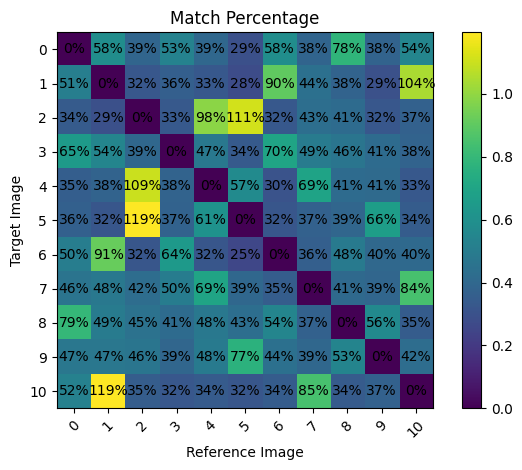

In [77]:
fig, ax = plt.subplots()

cax = ax.imshow(match_ratio)

# Add colorbar
plt.colorbar(cax)

# Axis labels (optional)
 
labels = [f"{i}" for i in range(n_images)]
ax.set_xticks(range(n_images))
ax.set_yticks(range(n_images))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

# Rotate x labels for readability
plt.xticks(rotation=45)

# Annotate each cell with value
for i in range(n_images):
    for j in range(n_images):
        display_value = f"{int(match_ratio[i, j]*100)}%"
        ax.text(j, i, display_value, ha="center", va="center")

plt.xlabel("Reference Image")
plt.ylabel("Target Image")
plt.title("Match Percentage")

plt.tight_layout()
plt.show()

In [78]:
fully_connected_graph = init_graph(n_images, match_ratio)

In [93]:
for ref_img_id in range(len(img_paths)):
    target_img_ids = get_k_closest_neighbors(fully_connected_graph, ref_img_id, 3)
    for target_img_id in target_img_ids:
        edge = fully_connected_graph[ref_img_id][target_img_id]
        current_ic = edge['data']
        if current_ic.valid_connection is not models.ValidConnection.CONNECTED:
            new_ic = get_connection_between(ref_img_id, target_img_id, img_id_bounds, kps, matching_df, threshold=0.1)
            if ic.valid_connection == models.ValidConnection.CONNECTED:
                fully_connected_graph[ref_img_id][target_img_id]['weight'] = new_ic.weight
                fully_connected_graph[ref_img_id][target_img_id]['data'] = new_ic
            elif new_ic.valid_connection == models.ValidConnection.NOTCONNECTED:
                fully_connected_graph.remove_edge(ref_img_id, target_img_id)

[autoreload of image_stitching.models failed: Traceback (most recent call last):
  File "/home/schmidtg/coding_projetcs/local-image-features-apps/.venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "/home/schmidtg/coding_projetcs/local-image-features-apps/.venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 580, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/importlib/__init__.py", line 131, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 991, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1129, in get_code
  File "<frozen importlib._bootstrap_external>", line 1059, in source_to_code
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "/home/schmidtg/coding_proje

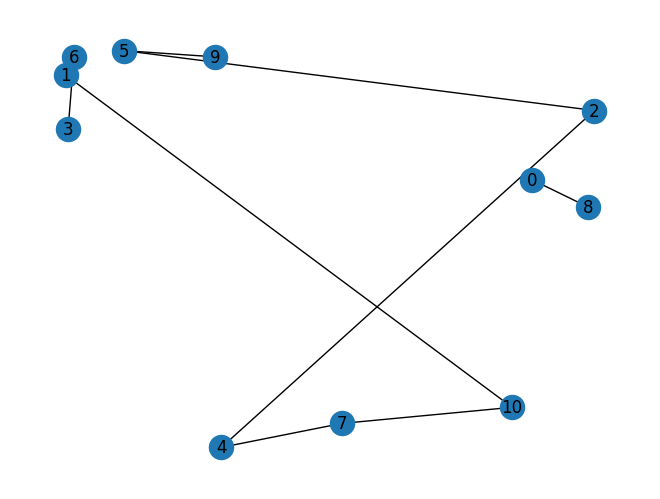

In [94]:
pos = nx.spring_layout(fully_connected_graph)

# Draw graph
nx.draw(fully_connected_graph, pos, with_labels=True)
plt.show()


0: medium08.jpg
1: medium11.jpg
2: medium04.jpg
3: medium09.jpg
4: medium03.jpg
5: medium05.jpg
6: medium10.jpg
7: medium02.jpg
8: medium07.jpg
9: medium06.jpg
10: medium01.jpg


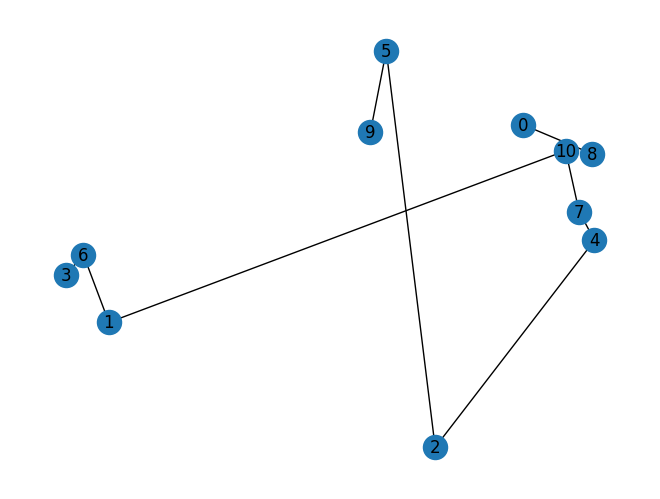

In [95]:
# optimised graph
pano_graph = nx.minimum_spanning_tree(fully_connected_graph)

pos = nx.spring_layout(pano_graph)

# Draw graph
nx.draw(pano_graph, pos, with_labels=True)

for i, path in enumerate(img_paths):
    print(f"{i}: {os.path.basename(path)}")
plt.show()

In [96]:
edge = fully_connected_graph[1][3]
edge['data']

KeyError: 3

In [ ]:
# Compute closeness centrality for all nodes
closeness = nx.closeness_centrality(pano_graph)

# Find the node with the highest centrality
best_node = max(closeness, key=closeness.get)

print("Best connected node:", best_node)

Best connected node: 1


In [8]:
d = {}
d[0] = "asas"
first_key = next(iter(d))
first_key

0